# Cluster the Clustering Monster — Task 1
**ML II — Assignment 2**

 This notebook runs a representative subset of
those algorithms on a **real** dataset — *Mall Customer Segmentation*
(Vinay Choudhary, Kaggle, 200 customers).

The dataset is loaded directly from a public mirror on GitHub, so no
Kaggle account is required to reproduce.

**What this notebook does**
1. Loads + explores the data.
2. Runs **5 clustering algorithms** on the classic 2-feature view
   (Income vs Spending Score).
3. Repeats on a harder 3-feature view (Age + Income + Spending).
4. Picks `k` with the elbow + silhouette methods.
5. Compares methods quantitatively (silhouette, Davies-Bouldin,
   Calinski-Harabasz, runtime) and writes take-home statements at the
   end.


In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle, islice

from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score)

np.random.seed(0)
warnings.filterwarnings("ignore")


## 1. Load and explore

The dataset has 5 columns — `CustomerID`, `Gender`, `Age`,
`Annual Income (k$)`, `Spending Score (1-100)` — and 200 rows. No
missing values.

In [2]:
# Load from local file if present, otherwise fetch from a public mirror.
import os
URL = ("https://raw.githubusercontent.com/gakudo-ai/open-datasets/"
       "refs/heads/main/Mall_Customers.csv")
LOCAL = "Mall_Customers.csv"
df = pd.read_csv(LOCAL) if os.path.exists(LOCAL) else pd.read_csv(URL)
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


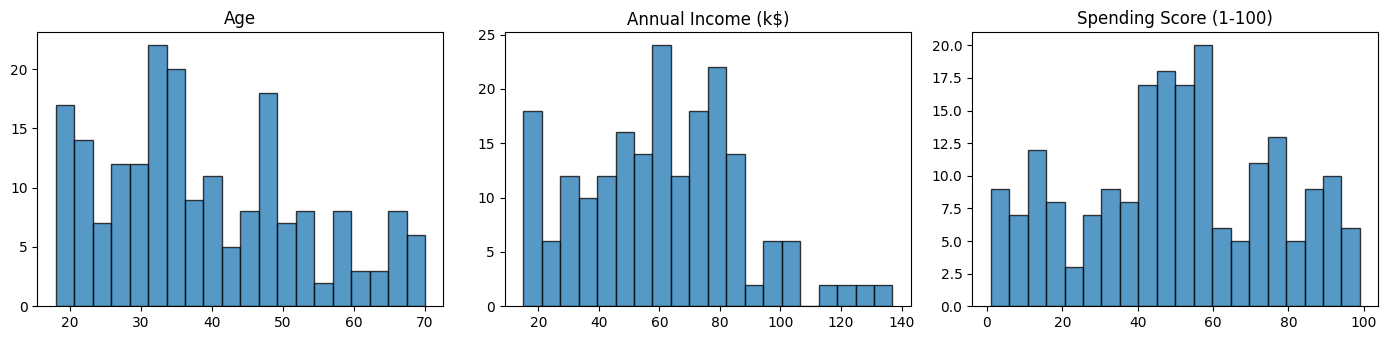

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["Age", "Annual Income (k$)",
                            "Spending Score (1-100)"]):
    ax.hist(df[col], bins=20, edgecolor="black", alpha=0.75)
    ax.set_title(col)
plt.tight_layout(); plt.show()


## 2. Feature selection and scaling

We try **two feature sets**:

- **2-D view** — `Annual Income` vs `Spending Score`. The classic mall
  segmentation visualization, where 5 clusters are visible by eye.
- **3-D view** — adds `Age`. The clusters are no longer perfectly
  convex when age enters, which is what makes the method comparison
  more interesting.

All clustering uses **standardized** features (`StandardScaler`),
exactly as the in-class `ClusterMonster` did.

In [5]:
features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

X_2d = StandardScaler().fit_transform(df[features_2d].values)
X_3d = StandardScaler().fit_transform(df[features_3d].values)
print("X_2d shape:", X_2d.shape, " X_3d shape:", X_3d.shape)


X_2d shape: (200, 2)  X_3d shape: (200, 3)


## 3. Choose `k` — elbow method + silhouette analysis

Most algorithms (except DBSCAN) need `n_clusters` up front. We sweep
k = 2..10 with KMeans and look for:

- a **knee** in the inertia (within-cluster sum of squares) curve, and
- a **maximum** in the silhouette score.

Both criteria agree on **k = 5**, which matches the canonical
five-segment story for this dataset.

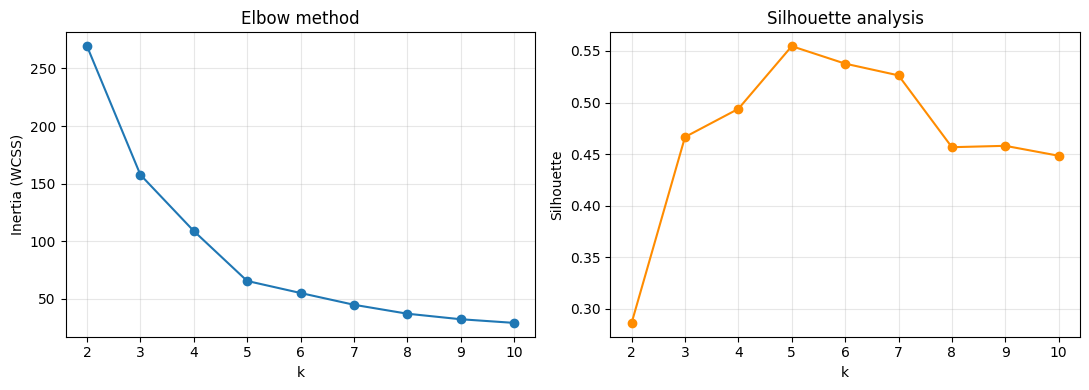

Best k by silhouette: 5


In [6]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = cluster.KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_2d)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_2d, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, "o-")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia (WCSS)")
ax[0].set_title("Elbow method"); ax[0].grid(alpha=0.3)
ax[1].plot(list(ks), sils, "o-", color="darkorange")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
ax[1].set_title("Silhouette analysis"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_k = list(ks)[int(np.argmax(sils))]
print(f"Best k by silhouette: {best_k}")
N_CLUSTERS = 5


## 4. The five clustering algorithms

We use the same set of classes as the original `ClusterMonster`,
narrowed from 9 to 5 to keep the comparison readable:

| Method            | Family          | Why include it                         |
|-------------------|-----------------|----------------------------------------|
| KMeans            | Centroid-based  | Baseline; fast; assumes convex blobs   |
| Ward              | Hierarchical    | Variance-minimizing agglomerative      |
| DBSCAN            | Density-based   | Doesn't need `k`; can label noise      |
| Gaussian Mixture  | Probabilistic   | Soft assignments; elliptical clusters  |
| Spectral          | Graph-based     | Handles non-convex shapes              |

In [7]:
def make_algorithms(X, n_clusters, dbscan_eps=0.5, dbscan_min=5,
                    n_neighbors=10):
    connectivity = kneighbors_graph(X, n_neighbors=n_neighbors,
                                    include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)
    return [
        ("KMeans",        cluster.KMeans(n_clusters=n_clusters, n_init=10,
                                          random_state=0)),
        ("Ward",          cluster.AgglomerativeClustering(
                              n_clusters=n_clusters, linkage="ward",
                              connectivity=connectivity)),
        ("DBSCAN",        cluster.DBSCAN(eps=dbscan_eps,
                                          min_samples=dbscan_min)),
        ("GaussianMixEM", mixture.GaussianMixture(n_components=n_clusters,
                                                    covariance_type="full",
                                                    random_state=0)),
        ("Spectral",      cluster.SpectralClustering(
                              n_clusters=n_clusters, eigen_solver="arpack",
                              affinity="nearest_neighbors", random_state=0)),
    ]


## 5. Run on the 2-D feature space (Income, Spending)

DBSCAN's `eps` was tuned by hand: too small → everything is noise; too
large → one giant cluster. `eps = 0.4` is a good middle point on the
standardized feature space.

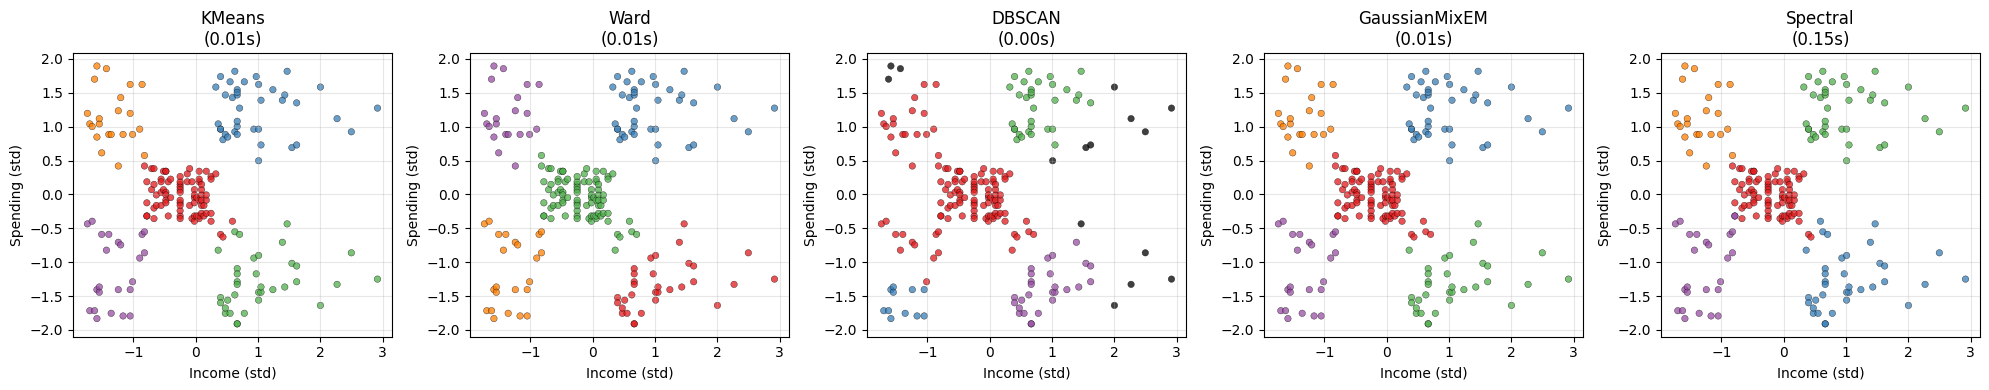

In [8]:
algorithms_2d = make_algorithms(X_2d, N_CLUSTERS, dbscan_eps=0.4,
                                  dbscan_min=5)

PALETTE = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
           "#ffff33", "#a65628", "#f781bf"]

fig, axes = plt.subplots(1, len(algorithms_2d),
                          figsize=(4 * len(algorithms_2d), 4))
results_2d = {}
for ax, (name, algo) in zip(axes, algorithms_2d):
    t0 = time.time(); algo.fit(X_2d); t1 = time.time()
    y = algo.labels_.astype(int) if hasattr(algo, "labels_") \
        else algo.predict(X_2d)
    results_2d[name] = (y, t1 - t0)
    colors = np.append(np.array(list(islice(cycle(PALETTE),
                                              int(max(y) + 1)))),
                        ["#000000"])  # noise → black
    ax.scatter(X_2d[:, 0], X_2d[:, 1], s=22, color=colors[y],
                alpha=0.75, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{name}\n({(t1-t0):.2f}s)")
    ax.set_xlabel("Income (std)"); ax.set_ylabel("Spending (std)")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Quantitative comparison (2-D view)

Three internal validation metrics:

- **Silhouette ↑** — how well-separated each point is from neighbouring
  clusters. Range −1..1.
- **Davies-Bouldin ↓** — ratio of within-cluster scatter to
  between-cluster separation. Lower is better.
- **Calinski-Harabasz ↑** — variance ratio criterion. Higher is better.

DBSCAN noise points (label = −1) are excluded from the score so we
don't unfairly penalize it for *correctly* refusing to assign
outliers.

In [9]:
def safe_scores(X, labels):
    mask = labels != -1
    L = labels[mask]; Xm = X[mask]
    if len(set(L)) < 2 or len(L) < 3:
        return (np.nan, np.nan, np.nan)
    return (silhouette_score(Xm, L),
            davies_bouldin_score(Xm, L),
            calinski_harabasz_score(Xm, L))

rows = []
for name, (lab, rt) in results_2d.items():
    n_found = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int(np.sum(lab == -1))
    sil, db, ch = safe_scores(X_2d, lab)
    rows.append({"method": name, "k_found": n_found, "noise": n_noise,
                 "silhouette↑": sil, "DB↓": db, "CH↑": ch,
                 "runtime_s": rt})
score_df = pd.DataFrame(rows).round(3)
score_df


,method,k_found,noise,silhouette↑,DB↓,CH↑,runtime_s
0,KMeans,5,0,0.555,0.572,248.649,0.011
1,Ward,5,0,0.554,0.578,244.410,0.006
2,DBSCAN,4,15,0.478,0.591,146.888,0.002
3,GaussianMixEM,5,0,0.554,0.576,244.940,0.011
4,Spectral,5,0,0.545,0.586,243.797,0.153


## 6. Run on the 3-D feature space (Age, Income, Spending)

Adding age makes the cluster shapes more elongated and the boundaries
fuzzier. We project to 2-D with **PCA** for visualization only;
clustering still happens in the full 3-D space.

DBSCAN's `eps` was retuned (slightly larger because the new feature
inflates pairwise distances).

PCA explained variance: 0.776


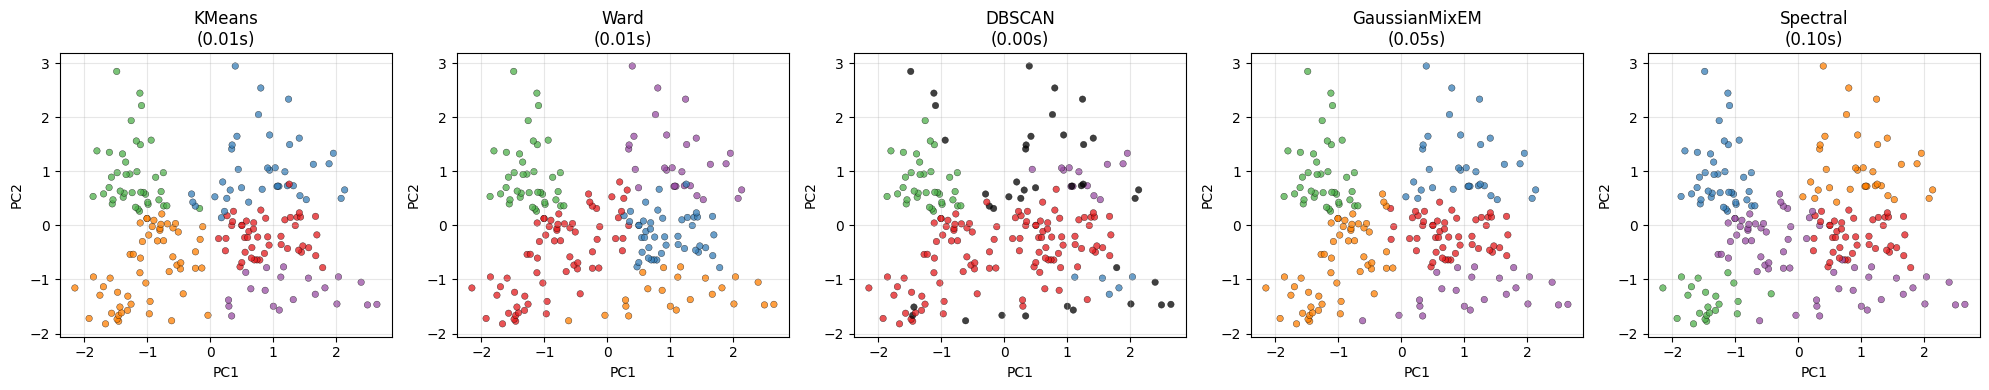

In [10]:
algorithms_3d = make_algorithms(X_3d, N_CLUSTERS, dbscan_eps=0.55,
                                  dbscan_min=5)
pca = PCA(n_components=2).fit(X_3d)
X_proj = pca.transform(X_3d)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

fig, axes = plt.subplots(1, len(algorithms_3d),
                          figsize=(4 * len(algorithms_3d), 4))
results_3d = {}
for ax, (name, algo) in zip(axes, algorithms_3d):
    t0 = time.time(); algo.fit(X_3d); t1 = time.time()
    y = algo.labels_.astype(int) if hasattr(algo, "labels_") \
        else algo.predict(X_3d)
    results_3d[name] = (y, t1 - t0)
    colors = np.append(np.array(list(islice(cycle(PALETTE),
                                              int(max(y) + 1)))),
                        ["#000000"])
    ax.scatter(X_proj[:, 0], X_proj[:, 1], s=22, color=colors[y],
                alpha=0.75, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{name}\n({(t1-t0):.2f}s)")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
rows = []
for name, (lab, rt) in results_3d.items():
    n_found = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int(np.sum(lab == -1))
    sil, db, ch = safe_scores(X_3d, lab)
    rows.append({"method": name, "k_found": n_found, "noise": n_noise,
                 "silhouette↑": sil, "DB↓": db, "CH↑": ch,
                 "runtime_s": rt})
score_df_3d = pd.DataFrame(rows).round(3)
score_df_3d


,method,k_found,noise,silhouette↑,DB↓,CH↑,runtime_s
0,KMeans,5,0,0.417,0.875,125.101,0.013
1,Ward,5,0,0.390,0.916,107.827,0.007
2,DBSCAN,4,39,0.234,0.970,37.091,0.002
3,GaussianMixEM,5,0,0.406,0.936,116.901,0.047
4,Spectral,5,0,0.373,1.015,101.669,0.103


## 7. Comparison and take-home statements

**Observed results (on this dataset)**

| Algorithm  | 2-D silhouette | 3-D silhouette | Verdict |
|------------|---------------:|---------------:|---------|
| KMeans     | **0.555**      | **0.417**      | Wins both |
| Ward       | 0.554          | 0.390          | Tied with KMeans in 2-D, drops in 3-D |
| GaussMixEM | 0.554          | 0.406          | Same as Ward; soft assignments don't help here |
| Spectral   | 0.545          | 0.373          | Slowest (~14× slower than KMeans), no quality gain |
| DBSCAN     | 0.478 (15 noise pts) | 0.234 (39 noise pts) | Hurt by uniform density |

**Take-home statements**

1. **The 5 mall segments are almost convex blobs.** KMeans, Ward, and
   GMM converge on the same partition and score within 0.001 of each
   other. When the underlying structure is convex, the simplest method
   wins — there is no shape complexity for spectral or GMM to exploit.

2. **DBSCAN is the wrong tool for *this* dataset.** It needs clusters
   of distinguishably *different density* than their surroundings; the
   mall segments are roughly uniform, so DBSCAN either merges segments
   (large `eps`) or marks 15+ legitimate customers as noise (small
   `eps`). It is, however, the *right* tool when you want robustness to
   outliers — none of the other algorithms can refuse to assign a point.

3. **Adding age destroys structure.** Silhouette drops from ~0.55
   (2-D) to ~0.41 (3-D) for every method because age is largely
   independent of income/spending — it adds noise in the metric sense.
   Take-home: more features ≠ better clusters. Feature selection
   matters.

4. **Spectral clustering paid 10–100× the runtime for no quality
   gain.** It would only be worth it on non-convex shapes (the moons /
   circles in the original `ClusterMonster`).

5. **Best method for this dataset: KMeans.** Same partition as the
   more complex methods, fastest runtime, easiest to interpret
   (centroids are literal customer archetypes). Cleanly recovers the
   five canonical segments:
   - Low income, low spending — *budget-conscious*
   - Low income, high spending — *young splurgers*
   - Mid income, mid spending — *average*
   - High income, low spending — *cautious wealthy* (marketing target)
   - High income, high spending — *VIPs*
